# 02. Aggregated Features Model

This notebook builds an improved credit default prediction model by creating customer-level aggregated features from each customer’s full statement history. Instead of relying only on the most recent statement, it summarizes past behavior using statistics such as mean, standard deviation, minimum, maximum, latest value, and statement count. This helps evaluate whether incorporating historical customer patterns leads to better predictive performance than the last-statement baseline model.


In [1]:
import os, gc, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from lightgbm import LGBMClassifier

pd.set_option("display.max_columns", 200)

os.makedirs("/kaggle/working/figures", exist_ok=True)
os.makedirs("/kaggle/working/results", exist_ok=True)
os.makedirs("/kaggle/working/data", exist_ok=True)

In [2]:
def find_file(filename):
    for dirname, _, filenames in os.walk("/kaggle/input"):
        if filename in filenames:
            return os.path.join(dirname, filename)
    raise FileNotFoundError(f"{filename} not found. Add AMEX datasets to Kaggle input.")

train_path = find_file("train_data_f32.ftr")

print("train_path:", train_path)

train_path: /kaggle/input/datasets/munumbutt/amexfeather/train_data_f32.ftr


In [3]:
def recall_at_top_k(y_true, y_pred_proba, k=0.04):
    y_true = pd.Series(y_true).reset_index(drop=True)
    y_pred_proba = pd.Series(y_pred_proba).reset_index(drop=True)

    n_top = max(1, int(len(y_pred_proba) * k))
    top_idx = y_pred_proba.sort_values(ascending=False).head(n_top).index

    return y_true.loc[top_idx].sum() / y_true.sum()


def evaluate_model(model_name, y_true, y_pred_proba, threshold=0.5):
    y_pred = (y_pred_proba >= threshold).astype(int)

    result = {
        "model": model_name,
        "roc_auc": roc_auc_score(y_true, y_pred_proba),
        "pr_auc": average_precision_score(y_true, y_pred_proba),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "recall_at_top_4pct": recall_at_top_k(y_true, y_pred_proba, k=0.04)
    }

    print(f"Model: {model_name}")
    for k, v in result.items():
        if k != "model":
            print(f"{k}: {v:.6f}")

    print("\nConfusion Matrix")
    print(confusion_matrix(y_true, y_pred))

    print("\nClassification Report")
    print(classification_report(y_true, y_pred, zero_division=0))

    return result

In [4]:
CAT_COLS = [
    "B_30", "B_38",
    "D_114", "D_116", "D_117", "D_120", "D_126",
    "D_63", "D_64", "D_66", "D_68"
]

def build_aggregated_dataset(train_path):
    train = pd.read_feather(train_path)

    train["S_2"] = pd.to_datetime(train["S_2"])
    train = train.sort_values(["customer_ID", "S_2"])

    num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
    num_cols = [c for c in num_cols if c not in CAT_COLS + ["target"]]

    agg_num = train.groupby("customer_ID")[num_cols].agg(
        ["mean", "std", "min", "max", "last"]
    )

    agg_num.columns = ["_".join(col) for col in agg_num.columns]
    agg_num = agg_num.reset_index()

    existing_cat_cols = [c for c in CAT_COLS if c in train.columns]

    if existing_cat_cols:
        agg_cat = train.groupby("customer_ID")[existing_cat_cols].last().reset_index()
        agg_cat.columns = ["customer_ID"] + [f"{c}_last" for c in existing_cat_cols]
        data = agg_num.merge(agg_cat, on="customer_ID", how="left")
    else:
        data = agg_num.copy()

    statement_count = train.groupby("customer_ID").size().reset_index(name="statement_count")
    data = data.merge(statement_count, on="customer_ID", how="left")

    target = train.groupby("customer_ID")["target"].last().reset_index()
    data = data.merge(target, on="customer_ID", how="left")

    del train
    gc.collect()

    return data

In [5]:
data_agg = build_aggregated_dataset(train_path)

print("data_agg:", data_agg.shape)
print("target columns:", [col for col in data_agg.columns if "target" in col])
print("missing target:", data_agg["target"].isna().sum())

display(data_agg.head())

data_agg: (458913, 899)
target columns: ['target']
missing target: 0


,customer_ID,P_2_mean,P_2_std,P_2_min,P_2_max,P_2_last,D_39_mean,D_39_std,D_39_min,D_39_max,D_39_last,B_1_mean,B_1_std,B_1_min,B_1_max,B_1_last,B_2_mean,B_2_std,B_2_min,B_2_max,B_2_last,R_1_mean,R_1_std,R_1_min,R_1_max,R_1_last,S_3_mean,S_3_std,S_3_min,S_3_max,S_3_last,D_41_mean,D_41_std,D_41_min,D_41_max,D_41_last,B_3_mean,B_3_std,B_3_min,B_3_max,B_3_last,D_42_mean,D_42_std,D_42_min,D_42_max,D_42_last,D_43_mean,D_43_std,D_43_min,D_43_max,D_43_last,D_44_mean,D_44_std,D_44_min,D_44_max,D_44_last,B_4_mean,B_4_std,B_4_min,B_4_max,B_4_last,D_45_mean,D_45_std,D_45_min,D_45_max,D_45_last,B_5_mean,B_5_std,B_5_min,B_5_max,B_5_last,R_2_mean,R_2_std,R_2_min,R_2_max,R_2_last,D_46_mean,D_46_std,D_46_min,D_46_max,D_46_last,D_47_mean,D_47_std,D_47_min,D_47_max,D_47_last,D_48_mean,D_48_std,D_48_min,D_48_max,D_48_last,D_49_mean,D_49_std,D_49_min,D_49_max,D_49_last,B_6_mean,B_6_std,B_6_min,B_6_max,...,B_42_max,B_42_last,D_130_mean,D_130_std,D_130_min,D_130_max,D_130_last,D_131_mean,D_131_std,D_131_min,D_131_max,D_131_last,D_132_mean,D_132_std,D_132_min,D_132_max,D_132_last,D_133_mean,D_133_std,D_133_min,D_133_max,D_133_last,R_28_mean,R_28_std,R_28_min,R_28_max,R_28_last,D_134_mean,D_134_std,D_134_min,D_134_max,D_134_last,D_135_mean,D_135_std,D_135_min,D_135_max,D_135_last,D_136_mean,D_136_std,D_136_min,D_136_max,D_136_last,D_137_mean,D_137_std,D_137_min,D_137_max,D_137_last,D_138_mean,D_138_std,D_138_min,D_138_max,D_138_last,D_139_mean,D_139_std,D_139_min,D_139_max,D_139_last,D_140_mean,D_140_std,D_140_min,D_140_max,D_140_last,D_141_mean,D_141_std,D_141_min,D_141_max,D_141_last,D_142_mean,D_142_std,D_142_min,D_142_max,D_142_last,D_143_mean,D_143_std,D_143_min,D_143_max,D_143_last,D_144_mean,D_144_std,D_144_min,D_144_max,D_144_last,D_145_mean,D_145_std,D_145_min,D_145_max,D_145_last,B_30_last,B_38_last,D_114_last,D_116_last,D_117_last,D_120_last,D_126_last,D_63_last,D_64_last,D_66_last,D_68_last,statement_count,target
0,3249127622875,1.003573,0.001341,1.002345,1.005004,1.005004,0.088271,0.200800,0.000390,0.621244,0.008411,0.008108,0.004341,0.000974,0.014857,0.005660,0.932826,0.097657,0.811644,1.009668,1.009403,0.005930,0.002705,0.001177,0.008771,0.007339,0.140968,0.044033,0.091621,0.224990,0.179448,0.004832,0.002766,0.000953,0.009718,0.004560,0.009518,0.005056,0.001070,0.018145,0.004012,NaN,NaN,NaN,NaN,NaN,0.114842,0.058349,0.043479,0.242577,0.107345,0.004525,0.003595,0.000957,0.008145,0.004473,0.008952,0.010414,0.001463,0.034932,0.028382,0.552715,0.010112,0.538817,0.569654,0.567501,0.007017,0.003436,0.002249,0.014812,0.008377,0.004572,0.002587,0.000477,0.009146,0.005527,NaN,NaN,NaN,NaN,NaN,0.438815,0.105067,0.378035,0.626452,0.620382,0.065910,0.012214,0.052290,0.075891,0.052290,NaN,NaN,NaN,NaN,NaN,2.070536,4.545935,0.195590,12.316238,...,NaN,NaN,0.005106,0.003222,0.000651,0.009623,0.005780,0.004079,0.003460,0.000794,0.009910,0.001284,NaN,NaN,NaN,NaN,NaN,0.006001,0.002713,0.000846,0.009912,0.004446,0.004149,0.003131,0.000385,0.009797,0.006051,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.005535,0.003037,0.000708,0.009517,0.006212,0.005252,0.003065,0.000966,0.009469,0.003949,0.005050,0.003300,0.000266,0.009407,0.006435,NaN,NaN,NaN,NaN,NaN,0.003673,0.003183,0.000143,0.008928,0.000439,0.005934,0.003247,0.000510,0.009815,0.000895,0.005011,0.002883,0.000674,0.008520,0.006147,0.0,2.0,1.0,0.0,4.0,1.0,1.0,CO,,NaN,6.0,13,0
1,23402014749356,0.415518,0.100825,0.188222,0.498842,0.215565,0.100123,0.136302,0.005283,0.441647,0.030713,0.569637,0.173722,0.461963,0.878662,0.872928,0.024636,0.003400,0.020004,0.029966,0.020936,0.330217,0.425201,0.000543,1.002690,1.002117,0.364866,0.125289,0.206318,0.650284,0.402358,0.004804,0.003160,0.001181,0.009746,0.001812,0.651621,0.127401,0.511142,0.851680,0.851680,NaN,NaN,NaN,NaN,NaN,1.209194,0.310234,0.604089,1.648602,0.985836,0.130363,0.002732,0.126324,0.134471,0.127954,0.143859,0.020630,0.118439,0.183084,0.163676,0.071888,0.009582,0.057746,0.087532,0.083874,0.012343,

In [6]:
def encode_aggregated_categoricals(df):
    df = df.copy()
    cat_last_cols = [f"{c}_last" for c in CAT_COLS if f"{c}_last" in df.columns]

    for col in cat_last_cols:
        df[col] = df[col].astype("category").cat.codes.astype("int16")

    return df

X = data_agg.drop(columns=["customer_ID", "target"])
X = encode_aggregated_categoricals(X)

y = data_agg["target"].astype(int)

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_valid.shape)

(367130, 897)
(91783, 897)


In [7]:
lgbm_agg_model = LGBMClassifier(
    n_estimators=1200,
    learning_rate=0.025,
    num_leaves=96,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
    force_col_wise=True,
    verbose=-1
)

lgbm_agg_model.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric="auc"
)

agg_pred = lgbm_agg_model.predict_proba(X_valid)[:, 1]

agg_result = evaluate_model(
    "LightGBM - Aggregated Features",
    y_valid,
    agg_pred
)

with open("/kaggle/working/results/02_classification_report_aggregated_lgbm.txt", "w") as f:
    f.write(classification_report(
        y_valid,
        (agg_pred >= 0.5).astype(int),
        zero_division=0
    ))

Model: LightGBM - Aggregated Features
roc_auc: 0.961023
pr_auc: 0.897353
precision: 0.739017
recall: 0.905285
f1: 0.813745
recall_at_top_4pct: 0.153286

Confusion Matrix
[[60419  7598]
 [ 2251 21515]]

Classification Report
              precision    recall  f1-score   support

           0       0.96      0.89      0.92     68017
           1       0.74      0.91      0.81     23766

    accuracy                           0.89     91783
   macro avg       0.85      0.90      0.87     91783
weighted avg       0.91      0.89      0.90     91783



In [8]:
results = pd.DataFrame([agg_result])
display(results)

results.to_csv("/kaggle/working/results/02_aggregated_features_results.csv", index=False)

,model,roc_auc,pr_auc,precision,recall,f1,recall_at_top_4pct
0,LightGBM - Aggregated Features,0.961023,0.897353,0.739017,0.905285,0.813745,0.153286


,feature,importance
4,P_2_last,806
9,D_39_last,761
59,B_4_last,678
39,B_3_last,564
79,D_46_last,542
56,B_4_std,506
25,S_3_mean,495
49,D_43_last,492
29,S_3_last,488
69,B_5_last,442


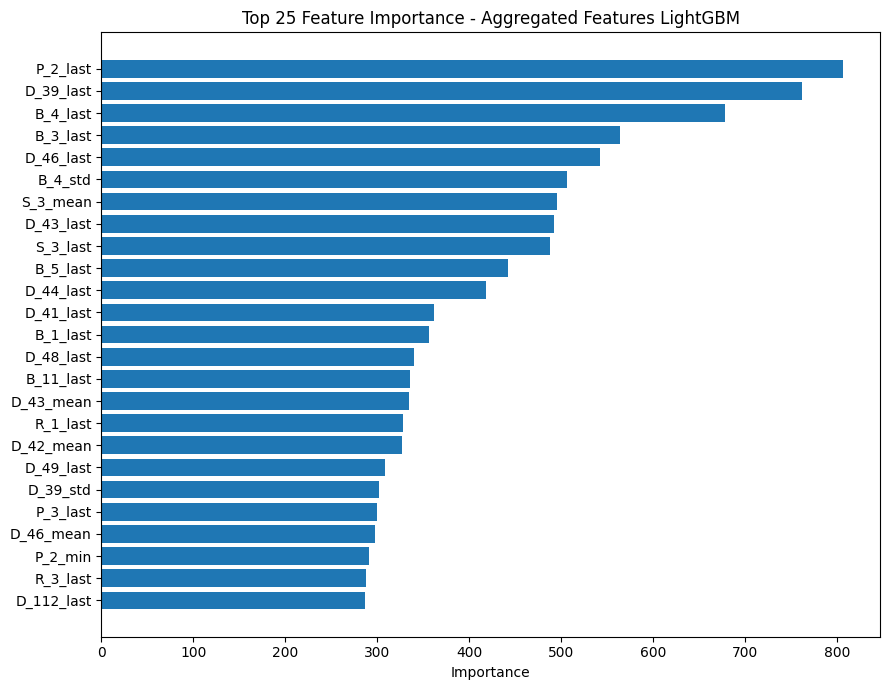

In [9]:
importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": lgbm_agg_model.feature_importances_
}).sort_values("importance", ascending=False)

display(importance.head(25))

importance.to_csv("/kaggle/working/results/02_feature_importance_aggregated.csv", index=False)

top = importance.head(25).sort_values("importance")

plt.figure(figsize=(9, 7))
plt.barh(top["feature"], top["importance"])
plt.title("Top 25 Feature Importance - Aggregated Features LightGBM")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("/kaggle/working/figures/02_feature_importance_aggregated.png", dpi=300)
plt.show()

In [10]:
data_agg.to_pickle("/kaggle/working/data/data_agg.pkl")

In [11]:
import os

for dirname, _, filenames in os.walk("/kaggle/working/figures"):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/working/figures/02_feature_importance_aggregated.png


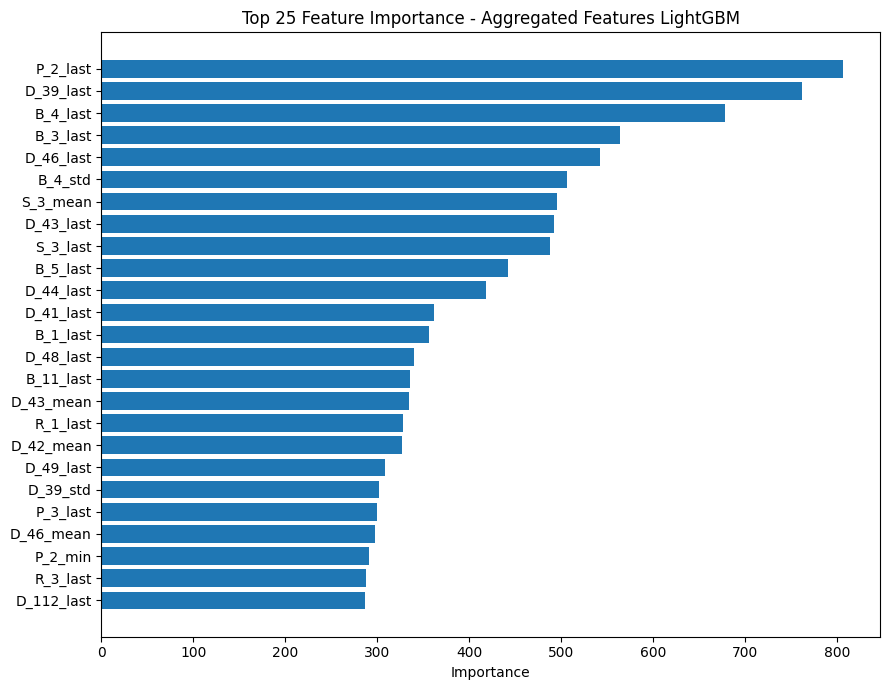

Figure file exists?: True
File size: 176585
Files in figures folder: ['02_feature_importance_aggregated.png']


In [12]:
import os
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs("/kaggle/working/figures", exist_ok=True)

importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": lgbm_agg_model.feature_importances_
}).sort_values("importance", ascending=False)

top = importance.head(25).sort_values("importance")

fig_path = "/kaggle/working/figures/02_feature_importance_aggregated.png"

plt.figure(figsize=(9, 7))
plt.barh(top["feature"], top["importance"])
plt.title("Top 25 Feature Importance - Aggregated Features LightGBM")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Figure file exists?:", os.path.exists(fig_path))
print("File size:", os.path.getsize(fig_path) if os.path.exists(fig_path) else "not found")
print("Files in figures folder:", os.listdir("/kaggle/working/figures"))